# Task 3: Correlation Between News Sentiment and Stock Movements

**Objective:**  
Align news headlines with stock prices, compute sentiment scores, calculate daily stock returns, and analyze correlations.

---

## 1. Setup & Data Loading

In [2]:
import pandas as pd

In [3]:
# Load stock data
stocks = pd.read_csv("../data/processed/stocks_full.csv", parse_dates=["Date"])
stocks = stocks[["Date", "Ticker", "Close"]].copy()
stocks = stocks.sort_values(['Ticker', 'Date'])

# Compute daily returns
stocks['Daily_Return'] = stocks.groupby('Ticker')['Close'].pct_change()
stocks.dropna(subset=['Daily_Return'], inplace=True)  # Drop first row per ticker

# Load cleaned news data
news = pd.read_csv("../data/processed/raw_analyst_ratings_clean.csv", parse_dates=["date"], index_col=0)
news.rename(columns={"date": "Date"}, inplace=True)
news = news[["Date", "headline", "stock"]].copy()

In [5]:
# Keep only news on trading days and valid tickers
news = news[news["Date"].isin(stocks["Date"].unique())]
news = news[news["stock"].isin(stocks["Ticker"].unique())]


In [6]:
# Quick Check
print(stocks.dtypes)
print(news.dtypes)
news

Date            datetime64[ns]
Ticker                  object
Close                  float64
Daily_Return           float64
dtype: object
Date        datetime64[ns]
headline            object
stock               object
dtype: object


,Date,headline,stock
7159,2020-06-02,'Apple is tracking iPhones stolen by looters' ...,AAPL
7160,2020-06-02,MoneyGram Shares Jump 50% As Western Union Rep...,AAPL
7161,2020-06-02,Hearing Susquehanna Check Suggests Total iPhon...,AAPL
7162,2020-06-02,Tesla CEO Musk Says Other Three Officers Shoul...,AAPL
7163,2020-06-02,A Peek Into The Markets: US Stock Futures Up; ...,AAPL
...,...,...,...
932184,2011-03-08,J.P. Morgan Upgrades NVIDIA Corporation To Neu...,NVDA
932185,2011-03-08,"JP Morgan Upgrades NVIDIA To Neutral, $21 PT",NVDA
932186,2011-03-07,Goldman Sachs Gives Color On Semiconductors (N...,NVDA
932187,2011-03-07,Auriga Still Not Sure Where Reality Lies For N...,NVDA


## 2. Sentiment Analysis

In [7]:
from textblob import TextBlob

def get_sentiment(text: str) -> float:
    """
    Compute sentiment polarity of a text.
    Returns:
        -1 (negative) to +1 (positive)
    """
    if not isinstance(text, str) or text.strip() == "":
        return 0.0
    return TextBlob(text).sentiment.polarity

In [8]:
# Compute sentiment first
news["sentiment_score"] = news["headline"].apply(get_sentiment)
# Aggregate daily sentiment per stock
daily_sentiment = (
    news.groupby(["Date", "stock"])["sentiment_score"]
        .mean()
        .reset_index()
        .rename(columns={"sentiment_score": "avg_sentiment"})
)

In [7]:
daily_sentiment

,Date,stock,avg_sentiment
0,2011-03-03,NVDA,-0.300000
1,2011-03-07,NVDA,-0.125000
2,2011-03-08,NVDA,0.000000
3,2011-03-09,NVDA,0.000000
4,2011-03-10,NVDA,0.500000
...,...,...,...
1522,2020-05-29,GOOG,0.058333
1523,2020-06-01,AAPL,0.036616
1524,2020-06-01,GOOG,0.116667
1525,2020-06-02,AAPL,-0.070833


## 3. Merge News and Stock Data

In [ ]:
merged = pd.merge(
    daily_sentiment,
    stocks[['Date', 'Ticker', 'Daily_Return']],
    left_on=['Date', 'stock'],
    right_on=['Date', 'Ticker'],
    how='inner'
)
merged.drop(columns=['Ticker'], inplace=True)  # Clean up
merged.dropna(subset=['Daily_Return'], inplace=True)


# Quick check
print(merged.shape)
merged.head()

(1527, 4)


,Date,stock,avg_sentiment,Daily_Return
0,2011-03-03,NVDA,-0.300,0.005783
1,2011-03-07,NVDA,-0.125,-0.013969
2,2011-03-08,NVDA,0.000,-0.044944
3,2011-03-09,NVDA,0.000,-0.020972
4,2011-03-10,NVDA,0.500,-0.063741


,Date,stock,avg_sentiment,Daily_Return
0,2011-03-03,NVDA,-0.300000,0.005783
1,2011-03-07,NVDA,-0.125000,-0.013969
2,2011-03-08,NVDA,0.000000,-0.044944
3,2011-03-09,NVDA,0.000000,-0.020972
4,2011-03-10,NVDA,0.500000,-0.063741
...,...,...,...,...
1522,2020-05-29,GOOG,0.058333,0.008604
1523,2020-06-01,AAPL,0.036616,0.012298
1524,2020-06-01,GOOG,0.116667,0.002030
1525,2020-06-02,AAPL,-0.070833,0.004629


## 4. Correlation Analysis

In [13]:
# Pearson correlation
pearson_corr = merged[['avg_sentiment', 'Daily_Return']].corr(method='pearson')
print("Pearson Correlation:\n", pearson_corr)

# Spearman correlation
spearman_corr = merged[['avg_sentiment', 'Daily_Return']].corr(method='spearman')
print("Spearman Correlation:\n", spearman_corr)

# Optional: Lagged return correlation (next-day effect)
merged['Daily_Return_next'] = merged.groupby('stock')['Daily_Return'].shift(-1)
lagged_corr = merged[['avg_sentiment', 'Daily_Return_next']].corr()
print("Lagged (Next-Day) Correlation:\n", lagged_corr)

Pearson Correlation:
                avg_sentiment  Daily_Return
avg_sentiment       1.000000      0.099226
Daily_Return        0.099226      1.000000
Spearman Correlation:
                avg_sentiment  Daily_Return
avg_sentiment       1.000000      0.126623
Daily_Return        0.126623      1.000000
Lagged (Next-Day) Correlation:
                    avg_sentiment  Daily_Return_next
avg_sentiment           1.000000          -0.016679
Daily_Return_next      -0.016679           1.000000


## 5. Visualizations

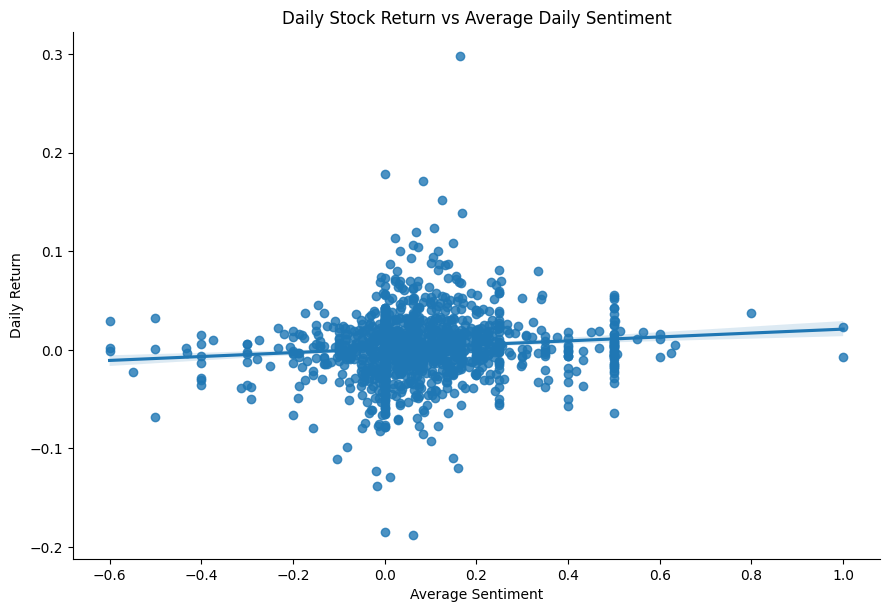

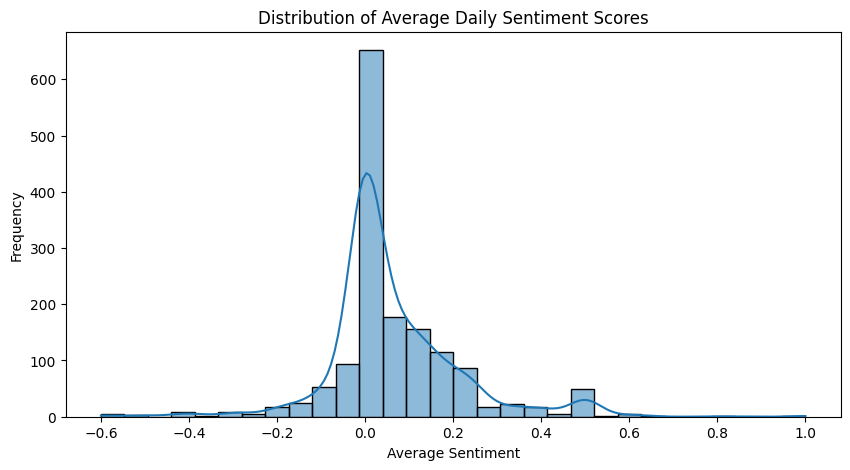

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Scatter plot with regression line
sns.lmplot(x='avg_sentiment', y='Daily_Return', data=merged, height=6, aspect=1.5)
plt.title("Daily Stock Return vs Average Daily Sentiment")
plt.xlabel("Average Sentiment")
plt.ylabel("Daily Return")
plt.show()



# Distribution of sentiment scores
plt.figure(figsize=(10,5))
sns.histplot(merged['avg_sentiment'], bins=30, kde=True)
plt.title("Distribution of Average Daily Sentiment Scores")
plt.xlabel("Average Sentiment")
plt.ylabel("Frequency")
plt.show()

## 6. Save Merged Data

In [ ]:
merged.to_csv("../data/processed/news_stock_merged.csv", index=False)